# Markov Chain Ensemble Using Recom

@author: taiyyoson

### Using 2018 Election Data

In [1]:
import pandas as pd
import geopandas as gpd
import maup
import matplotlib.pyplot as plt
from gerrychain import Graph, Partition, proposals, updaters, constraints, accept, MarkovChain, Election
from gerrychain.tree import bipartition_tree
from gerrychain.updaters import cut_edges, Tally
from gerrychain.proposals import recom
from gerrychain.accept import always_accept
from functools import partial
from gerrychain.metrics import efficiency_gap

import time
import os

In [2]:
## making graph
sc_graph = Graph.from_file("./SC/SC.shp")
sc_gdf = gpd.read_file("./SC/SC.shp")
sc_from_gpd_graph = Graph.from_geodataframe(sc_gdf, adjacency="rook") ## creating graph from geodataframe

In [3]:
## printing graph node information fields
sc_graph.nodes[1]

{'boundary_node': False,
 'area': 8648536.552029321,
 'COUNTY': '013',
 'PCODE': '111',
 'CODE_NAME': 'Burton 1B',
 'G20PRER': 160,
 'G20PRED': 650,
 'G20USSR': 142,
 'G20USSD': 679,
 'G20USSCBLE': 7,
 'TOTPOP': 2305,
 'P0020002': 383,
 'P0020005': 591,
 'P0020006': 1203,
 'P0020007': 5,
 'P0020008': 25,
 'P0020009': 1,
 'P0020010': 19,
 'P0020011': 78,
 'VAP': 1623,
 'HVAP': 1534,
 'P0030005': 5,
 'P0030006': 22,
 'P0030007': 1,
 'P0030008': 156,
 'P0030009': 89,
 'P0030010': 84,
 'P0030011': 13,
 'BVAP': 894,
 'P0030016': 1,
 'P0030017': 0,
 'P0030018': 0,
 'P0030019': 7,
 'P0030027': 1,
 'P0030028': 0,
 'P0030029': 0,
 'P0030030': 2,
 'P0030037': 0,
 'P0030038': 0,
 'P0030039': 0,
 'P0030040': 0,
 'P0030041': 0,
 'P0030042': 0,
 'P0030048': 0,
 'P0030049': 0,
 'P0030050': 0,
 'P0030051': 0,
 'P0030052': 0,
 'P0030053': 0,
 'P0030058': 0,
 'P0030059': 0,
 'P0030060': 0,
 'P0030061': 0,
 'P0030064': 0,
 'P0030065': 0,
 'P0030066': 0,
 'P0030067': 0,
 'P0030069': 0,
 'P0030071': 0,
 'A

In [4]:
## setting up initial markov chain model

## functions for markov chain updaters
def num_cut_edges(partition):
    return len(partition['cut_edges'])

def democratic_wins(partition):
    return sum(
        1 for district in partition.parts 
        if sum(partition.graph.nodes[node]["G18ATGD"] for node in district) > 
           sum(partition.graph.nodes[node]["G18ATGR"] for node in district)
    )

elections = [
    Election("G18ATG", {"Democratic": "G18ATGD", "Republican": "G18ATGR"}),
    Election("G18SOS", {"Democratic": "G18SOSD", "Republican": "G18SOSR"}),
    Election("G18GOV", {"Democratic": "G18GOVD", "Republican": "G18GOVR"}),
    Election("G18TRE", {"Democratic": "G18TRED", "Republican": "G18TRE"})]
election_updaters = {election.name: election for election in elections}

my_updaters = {
        "cut_edges": cut_edges,
        "population": Tally("TOTPOP", alias="population"),
        "democratic_wins": democratic_wins,
        "number_cut_edges": num_cut_edges,
    }
my_updaters.update(election_updaters)

## creating initial partition
initial_partition = Partition(
    sc_graph, 
    assignment="SEND",
    updaters=my_updaters
)

## using RECOM on the random walk, need ideal population
ideal_population = sum(initial_partition["population"].values()) / len(initial_partition)
proposal = partial(recom,
                   pop_col="TOTPOP",
                   pop_target=ideal_population,
                   epsilon=0.1,
                   node_repeats=2,
                   method = partial(
                        bipartition_tree,
                        max_attempts=100,
                        allow_pair_reselection=True  # <-- This is the only change
                    )
)


## all used for building markov chain
compactness_bound = constraints.UpperBound(
    lambda p: len(p["cut_edges"]),
    2*len(initial_partition["cut_edges"])
)
pop_constraint = constraints.within_percent_of_ideal_population(initial_partition, 0.1)





at step 0 the time is 0.0
at step 50 the time is 0.2779991626739502
at step 100 the time is 0.5889990329742432
at step 150 the time is 0.913999080657959
at step 200 the time is 1.2140257358551025
at step 250 the time is 1.5920519828796387
at step 300 the time is 1.8200531005859375
at step 350 the time is 2.092827320098877
at step 400 the time is 2.3304455280303955
at step 450 the time is 2.604454517364502
at step 500 the time is 2.86745548248291
at step 550 the time is 3.126473903656006
at step 600 the time is 3.4444756507873535
at step 650 the time is 3.750502109527588
at step 700 the time is 3.975501537322998
at step 750 the time is 4.234310150146484
at step 800 the time is 4.476451635360718
at step 850 the time is 4.7334511280059814
at step 900 the time is 5.041475772857666
at step 950 the time is 5.321474552154541
at step 1000 the time is 5.652475833892822
at step 1050 the time is 5.875476837158203
at step 1100 the time is 6.159474849700928
at step 1150 the time is 6.39206385612487

c:\Anaconda\envs\gerry\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 20000/20000 [01:48<00:00, 183.96it/s]


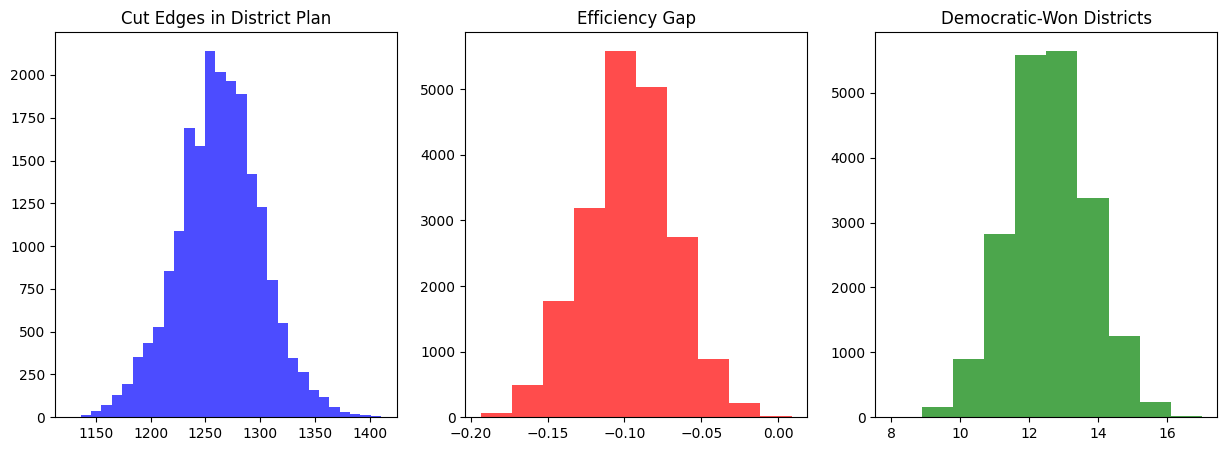

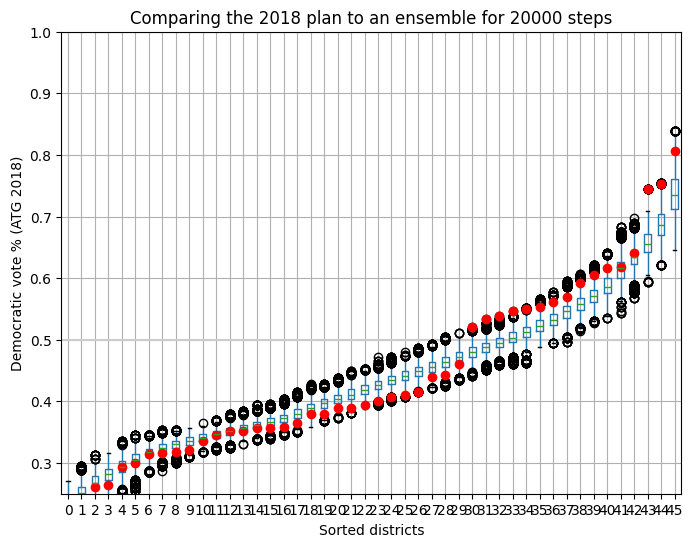

finished run 1 with 20000 steps
at step 0 the time is 0.0
at step 50 the time is 0.2889397144317627
at step 100 the time is 0.526940107345581
at step 150 the time is 0.8108575344085693
at step 200 the time is 1.0868701934814453
at step 250 the time is 1.4109199047088623
at step 300 the time is 1.6530749797821045
at step 350 the time is 1.9610776901245117
at step 400 the time is 2.21307635307312
at step 450 the time is 2.4837822914123535
at step 500 the time is 2.7738125324249268
at step 550 the time is 3.050812005996704
at step 600 the time is 3.3318123817443848
at step 650 the time is 3.6038014888763428
at step 700 the time is 3.8898844718933105
at step 750 the time is 4.1343162059783936
at step 800 the time is 4.389314651489258
at step 850 the time is 4.663271427154541
at step 900 the time is 4.944270610809326
at step 950 the time is 5.351271152496338
at step 1000 the time is 5.597285270690918
at step 1050 the time is 5.858285188674927
at step 1100 the time is 6.149286270141602
at st

100%|██████████| 40000/40000 [03:41<00:00, 180.72it/s]


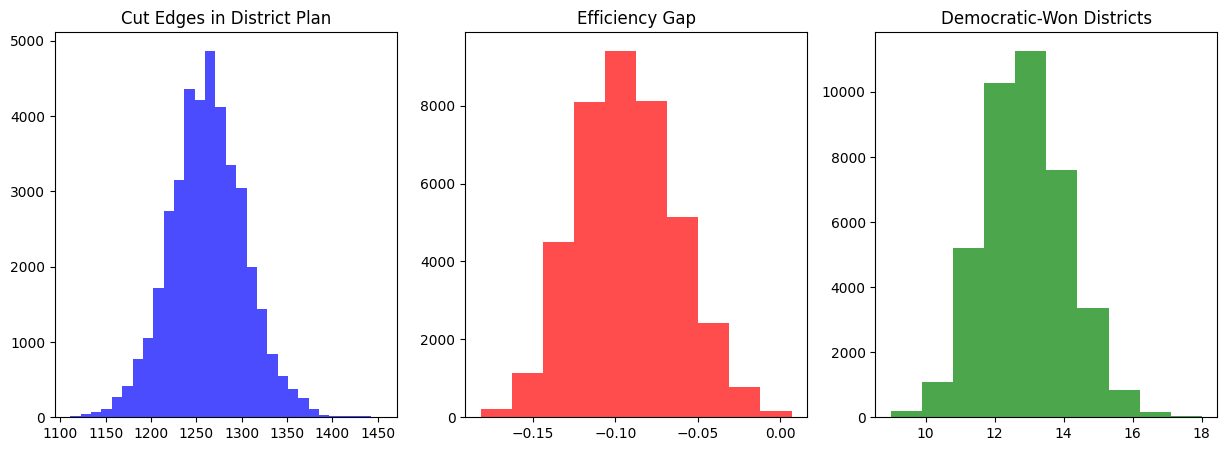

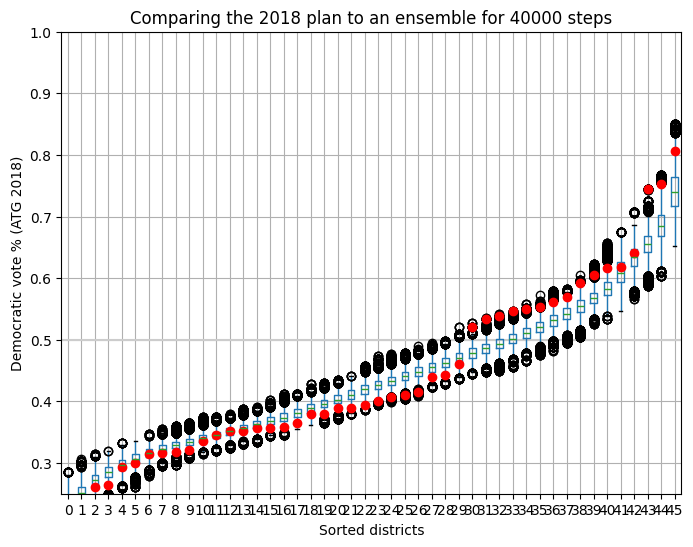

finished run 2 with 40000 steps


In [5]:
## running markov chain random walk (using recom proposal)
num_steps = 20000
for i in range(2):
    chain = MarkovChain(
        proposal=proposal,
        constraints=[compactness_bound, pop_constraint],
        accept=accept.always_accept,
        initial_state=initial_partition,
        total_steps=num_steps ## sample step count for now
    )
    
    cut_edges_list = []
    dem_wins_list = []
    EG_list = []
    start_time = time.time()
    for step, part in enumerate(chain):
        if step%50 == 0:
            print(f"at step {step} the time is {time.time() - start_time}")
        cut_edges_list.append(part["number_cut_edges"])
        dem_wins_list.append(part["G18ATG"].seats("Democratic"))
        EG_list.append(part["G18ATG"].efficiency_gap())
        
    ## plotting histograms
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].hist(cut_edges_list, bins=30, color='blue', alpha=0.7)
    axes[0].set_title("Cut Edges in District Plan")

    axes[1].hist(EG_list, bins=10, color='red', alpha=0.7)
    axes[1].set_title("Efficiency Gap")

    axes[2].hist(dem_wins_list, bins=10, color='green', alpha=0.7)
    axes[2].set_title("Democratic-Won Districts")
    
    ## making df for marginal box plots
    data = pd.DataFrame(
    sorted(partition["G18ATG"].percents("Democratic"))
    for partition in chain.with_progress_bar()
    )
    
    
    fig, ax = plt.subplots(figsize=(8, 6))

    # Draw 50% line
    ax.axhline(0.5, color="#cccccc")
    # Draw boxplot
    data.boxplot(ax=ax, positions=range(len(data.columns)))
    # Draw initial plan's Democratic vote %s (.iloc[0] gives the first row, which corresponds to the initial plan)
    plt.plot(data.iloc[0], "ro")
    # Annotate
    ax.set_title(f"Comparing the 2018 plan to an ensemble for {num_steps} steps")
    ax.set_ylabel("Democratic vote % (ATG 2018)")
    ax.set_xlabel("Sorted districts")
    ax.set_ylim(0.25, 1)
    ax.set_yticks([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
    plt.savefig(f'SCbox_plotATG2018_{i}.png')
    plt.show()
    

    print(f"finished run {i+1} with {num_steps} steps")
    num_steps *= 2
        
